# Ride-Hailing Fare Surge Prediction

## SUL Project

Ride-hailing platforms such as Uber and Lyft use surge pricing during periods of high demand. Surge pricing increases ride fares when demand exceeds the available supply of drivers.

The objective of this project is to analyze ride-hailing data and identify the factors affecting surge pricing. The dataset used is a raw dataset obtained from Kaggle containing ride details such as distance, cab type, source, destination, weather conditions, and ride price.

The project focuses on the following tasks:

• Data Cleaning  
• Exploratory Data Analysis (EDA)  
• Feature Selection  
• Feature Encoding  
• Machine Learning Model for Surge Prediction  

The cleaned dataset will be prepared for predictive modeling.

## Problem Statement
The objective of this project is to analyze ride-hailing data and prepare a clean dataset for surge price prediction. The dataset contains missing values, duplicates and irrelevant features which need to be cleaned before analysis.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load the Raw Dataset

In [2]:
df = pd.read_csv("dirty_dataset.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50500, 57)


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,ad4dc1c8-74e4-4018-aefe-be4e4b8e1ee5,1.545085e+09,33.156787,4.644655,NaN,2018-12-17 22:20:10,America/New_York,NaN,Theatre District,Uber,...,-2.716518,1.545066e+09,NaN,1.545044e+09,42.264830,1.545077e+09,27.265206,1.545044e+09,25.853683,1.545077e+09
1,47547461-f88b-4c14-9920-1d4a79e7025f,NaN,0.163429,20.949164,10.504201,NaN,America/New_York,Northeastern University,Theatre District,Lyft,...,-4.449973,1.543338e+09,44.462171,1.543378e+09,35.645204,1.543320e+09,31.493308,1.543378e+09,47.439069,1.543320e+09
2,45fba16d-75f1-4e10-bbb7-614f7f1624ae,1.543701e+09,22.287383,-1.762776,1.638907,2018-12-01 21:57:56,America/New_York,Beacon Hill,North End,Uber,...,4.982029,NaN,31.372425,1.543662e+09,44.366804,1.543691e+09,20.175919,1.543662e+09,44.913373,1.543691e+09
3,79ff5573-1bd4-406d-91c3-5e9b2b60d2b2,1.544794e+09,23.409993,9.777382,13.210001,2018-12-14 13:20:11,America/New_York,Haymarket Square,Beacon Hill,Uber,...,-8.286703,1.544807e+09,24.863769,1.544782e+09,36.492216,1.544814e+09,NaN,1.544785e+09,47.514452,1.544818e+09
4,80e33aa2-c291-41f0-b88d-adb3616bf154,1.544851e+09,7.624901,14.015315,15.645003,2018-12-15 05:20:11,NaN,North End,West End,Lyft,...,-0.687919,1.544893e+09,35.691489,1.544929e+09,50.189407,1.544897e+09,29.142550,1.544929e+09,63.281278,1.544897e+09


## Null count check

In [3]:
df.isnull().sum()

id                             5052
timestamp                      5057
hour                           5046
day                            5055
month                          5050
datetime                       5054
timezone                       5043
source                         5056
destination                    5055
cab_type                       5043
product_id                     5040
name                           5051
price                          8655
distance                       5055
surge_multiplier               5044
latitude                       5049
longitude                      5051
temperature                    5056
apparentTemperature            5050
short_summary                  5048
long_summary                   5051
precipIntensity                5045
precipProbability              5041
humidity                       5046
windSpeed                      5053
windGust                       5060
windGustTime                   5052
visibility                  

## Duplicates count Check

In [4]:
df.duplicated().sum()

500

## Step 3: Data Reduction (Sampling for Faster Analysis)

In [5]:
df = df.sample(50000, random_state=42)

## Step 4: Introducing Missing Data Mechanisms (MCAR, MAR, MNAR)

To simulate real-world dirty data, we artificially introduce three types of missing data patterns:

- MCAR (Missing Completely at Random)
- MAR (Missing At Random)
- MNAR (Missing Not At Random)

This helps us test how well our cleaning and preprocessing pipeline handles different missing data mechanisms.

In [6]:
df_dirty = df.copy()

np.random.seed(42)

### 4.1 MCAR (Missing Completely At Random)

MCAR means the missing values occur completely randomly and are not related to any other variable.

In [7]:
mcar_indices = np.random.choice(df_dirty.index, size=int(0.05*len(df_dirty)), replace=False)
df_dirty.loc[mcar_indices, 'price'] = np.nan

### 4.2 MAR (Missing At Random)

MAR means missing values depend on another feature in the dataset.
For example, price may be missing more often during high demand periods.

In [8]:
mar_condition = df_dirty['surge_multiplier'] > 2
mar_indices = df_dirty[mar_condition].sample(frac=0.1, random_state=42).index

df_dirty.loc[mar_indices, 'price'] = np.nan

### 4.3 MNAR (Missing Not At Random)

MNAR occurs when the missing value depends on the value itself.
For example, higher prices may be more likely to be missing.

In [9]:
threshold = df_dirty['price'].quantile(0.75)

mnar_condition = df_dirty['price'] > threshold
mnar_indices = df_dirty[mnar_condition].sample(frac=0.1, random_state=42).index

df_dirty.loc[mnar_indices, 'price'] = np.nan

## Before cleaning

Before Cleaning Total Missing: 288542


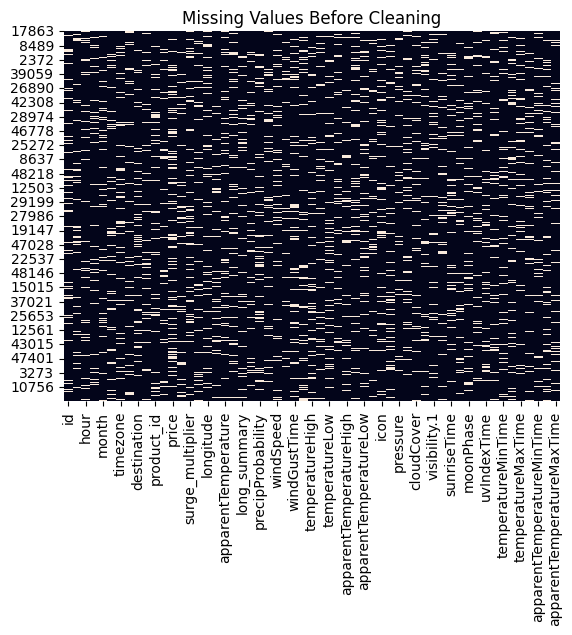

In [10]:
print("Before Cleaning Total Missing:", df.isnull().sum().sum())
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()

## After Cleaning

After Cleaning Total Missing: 0


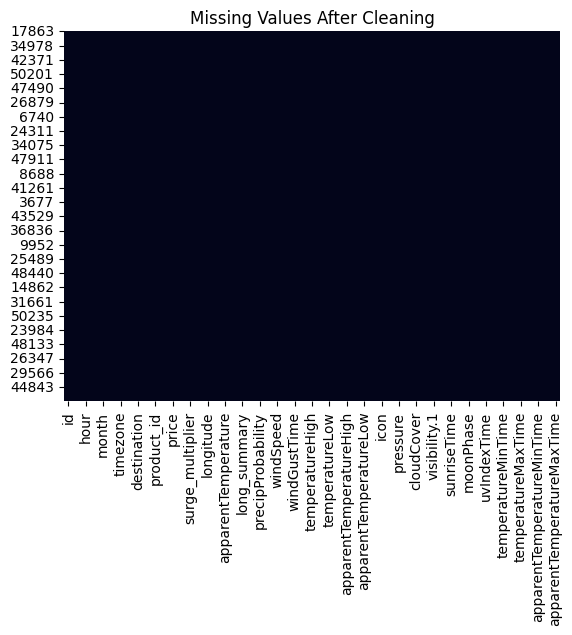

In [11]:

for col in df.columns:
    
    if df[col].dtype in ['int64', 'float64']:
        
        if df[col].isnull().sum() > 0:
            skew = df[col].skew()
            
            # MCAR (normal distribution)
            if -0.5 < skew < 0.5:
                df[col] = df[col].fillna(df[col].mean())
            
            # MAR / MNAR (skewed)
            else:
                df[col] = df[col].fillna(df[col].median())
    
    else:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])


df = df.dropna()


df = df.drop_duplicates()

print("After Cleaning Total Missing:", df.isnull().sum().sum())

sns.heatmap(df.isnull(), cbar=False)66
plt.title("Missing Values After Cleaning")
plt.show()

## Step 5: Dataset Understanding

In this step we explore the dataset structure including number of rows, columns, data types and sample records.

In [12]:
print("Dataset Shape:", df.shape)
print("\nColumns in Dataset:")
print(df.columns)
print("\nDataset Information:")
df.info()

print()
df_dirty.head()

Dataset Shape: (49504, 57)

Columns in Dataset:
Index(['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone',
       'source', 'destination', 'cab_type', 'product_id', 'name', 'price',
       'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature',
       'apparentTemperature', 'short_summary', 'long_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'windGustTime', 'visibility', 'temperatureHigh',
       'temperatureHighTime', 'temperatureLow', 'temperatureLowTime',
       'apparentTemperatureHigh', 'apparentTemperatureHighTime',
       'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon',
       'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex',
       'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase',
       'precipIntensityMax', 'uvIndexTime', 'temperatureMin',
       'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime',
       'apparentTemperatureMin', 'appar

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
17863,5066b6e1-4200-4c3b-8f64-d5efde9e2c34,NaN,6.208241,1.709763,18.746529,2018-12-03 08:53:02,America/New_York,North Station,South Station,NaN,...,1.101770,1.543853e+09,NaN,1.543896e+09,67.402172,NaN,39.472905,NaN,62.556873,1.543853e+09
9549,fa897641-2545-4e33-96f4-fcd9726cecb0,NaN,20.084061,33.311684,6.112180,2018-11-29 14:57:57,America/New_York,South Station,Beacon Hill,Lyft,...,-7.254370,1.543511e+09,29.969116,1.543550e+09,40.718759,NaN,33.784997,1.543550e+09,33.583331,1.543511e+09
45510,62bb0022-a820-44b9-8c1d-70a02e60b13b,1.543428e+09,27.126780,25.789551,5.767327,2018-11-28 17:56:26,America/New_York,Beacon Hill,North End,Uber,...,4.492653,1.543421e+09,31.666452,1.543399e+09,44.626105,1.543439e+09,19.097819,1.543399e+09,37.529263,1.543439e+09
39180,b50d5398-0b3b-4435-8ab4-8946cde26cc5,1.543217e+09,NaN,23.389849,12.028111,2018-11-26 07:24:58,America/New_York,North End,Back Bay,Uber,...,1.555876,NaN,43.772520,1.543234e+09,46.348868,1.543255e+09,44.613082,1.543291e+09,44.326502,NaN
23366,d2af2d84-bc4b-4aed-a9f8-8618706941ee,1.543763e+09,11.368082,1.049150,11.009823,2018-12-02 14:57:56,America/New_York,Financial District,Northeastern University,Uber,...,-4.468696,1.543770e+09,29.379571,1.543727e+09,51.151873,1.543788e+09,34.126067,1.543748e+09,45.609473,1.543788e+09


## Dataset Feature Description

The dataset contains several features describing ride details and pricing information. The key features used in this analysis are described below:

| Feature | Description |
|--------|-------------|
| distance | Distance of the ride in miles |
| cab_type | Type of cab service (Uber or Lyft) |
| source | Pickup location of the ride |
| destination | Drop-off location of the ride |
| surge_multiplier | Surge pricing factor applied during high demand |
| price | Final ride fare charged to the customer |

These features are selected for analysis because they directly influence ride pricing and demand patterns.

## Statistical Summary

This step provides statistical information about numerical features such as mean, standard deviation and distribution.

In [13]:
df.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,4.950400e+04,49504.000000,49504.000000,49504.000000,49504.000000,49504.000000,49504.000000,49504.000000,49504.000000,49504.000000,...,49504.000000,4.950400e+04,49504.000000,4.950400e+04,49504.000000,4.950400e+04,49504.000000,4.950400e+04,49504.000000,4.950400e+04
mean,2.172821e+09,16.383618,25.087849,16.277759,22.445381,3.075429,1.363681,59.592423,-99.731222,55.784905,...,0.054091,2.165235e+09,47.180161,2.163827e+09,63.562961,2.159070e+09,41.804411,2.172821e+09,59.037413,2.165247e+09
std,2.888414e+09,29.451333,41.981543,24.429741,37.478227,12.846987,11.816507,79.900435,132.835109,76.711416,...,11.636721,2.871754e+09,65.249416,2.868665e+09,85.965334,2.858124e+09,58.836786,2.888415e+09,80.919131,2.871780e+09
min,1.543204e+09,-142.444907,-144.470899,-69.696078,-88.656206,-182.838299,-164.491603,20.451770,-901.430130,1.611957,...,-166.777346,1.543162e+09,-1.311984,1.543122e+09,16.816170,1.543154e+09,-30.696149,1.543136e+09,14.361087,1.543187e+09
25%,1.543465e+09,6.328222,11.267429,8.851610,10.402464,-0.893732,-2.096735,39.663174,-74.525697,35.615976,...,-2.999806,1.543421e+09,29.720109,1.543403e+09,41.185015,1.543439e+09,26.229891,1.543399e+09,36.825641,1.543439e+09
50%,1.543773e+09,12.239712,19.283749,11.917749,15.533262,2.295997,1.012586,42.674804,-71.372847,40.627797,...,0.051898,1.543770e+09,34.742255,1.543727e+09,45.495016,1.543788e+09,31.117185,1.543748e+09,41.768984,1.543788e+09
75%,1.544843e+09,18.096052,26.905545,15.117321,22.421022,5.512124,4.166343,45.879476,-68.323252,45.420180,...,3.138927,1.544807e+09,39.397238,1.544789e+09,50.357494,1.544814e+09,35.871063,1.544789e+09,47.786708,1.544818e+09
max,1.545161e+10,361.687626,475.221267,302.696997,696.124584,198.636124,181.728714,587.180535,-49.974583,676.864593,...,170.344127,1.545152e+10,554.142956,1.545192e+10,726.433879,1.545109e+10,538.258795,1.545134e+10,699.720997,1.545109e+10


## Step 6: Data Cleaning and Preprocessing

Raw datasets often contain missing values, duplicate records and irrelevant features.  
In this step we clean the dataset to improve data quality and prepare it for analysis and machine learning.

### Step 6.1 Checking Missing Values

In [14]:
df_dirty.isnull().sum()

id                              4998
timestamp                       5019
hour                            4990
day                             4997
month                           4989
datetime                        5015
timezone                        4986
source                          5015
destination                     5006
cab_type                        4989
product_id                      4994
name                            5001
price                          13061
distance                        5005
surge_multiplier                4994
latitude                        4996
longitude                       5010
temperature                     4994
apparentTemperature             5002
short_summary                   5000
long_summary                    5006
precipIntensity                 4993
precipProbability               5001
humidity                        4997
windSpeed                       4996
windGust                        4995
windGustTime                    5002
v

### Step 6.2 Removing Duplicate Records

In [15]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

### Step 6.3 Outlier Detection

Outliers in numerical features were analyzed using the Interquartile Range (IQR) method
and boxplot visualization. Columns such as price, distance, and surge_multiplier were
examined for extreme values.

In ride-sharing datasets, high values often occur due to surge pricing during peak demand.
Therefore, outliers were analyzed but not removed to preserve realistic pricing patterns.

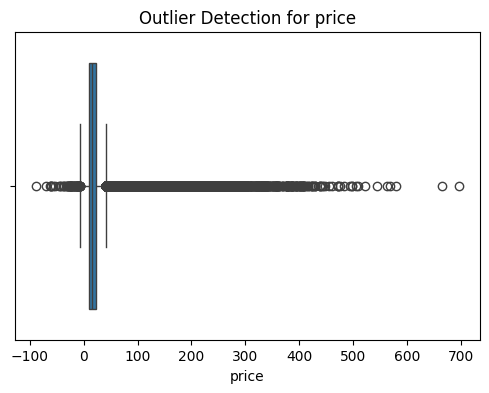

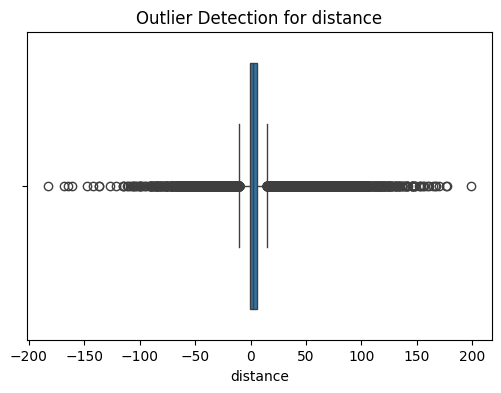

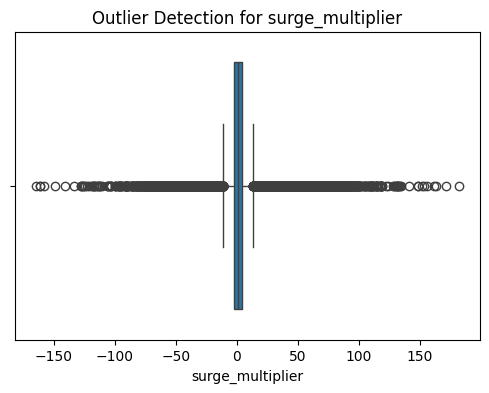

In [16]:
num_cols = ['price', 'distance', 'surge_multiplier']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

In [17]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "Outliers:", len(outliers))

price Outliers: 2794
distance Outliers: 2387
surge_multiplier Outliers: 2281


### Step 6.4 Removing Irrelevant Features

In [18]:
df.drop(['id','product_id'], axis=1, inplace=True, errors='ignore')

## Step 7: Dataset After Cleaning

This section compares the dataset before and after cleaning to observe the impact of preprocessing.

In [19]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (49504, 55)


## Step 8: Exploratory Data Analysis (EDA)

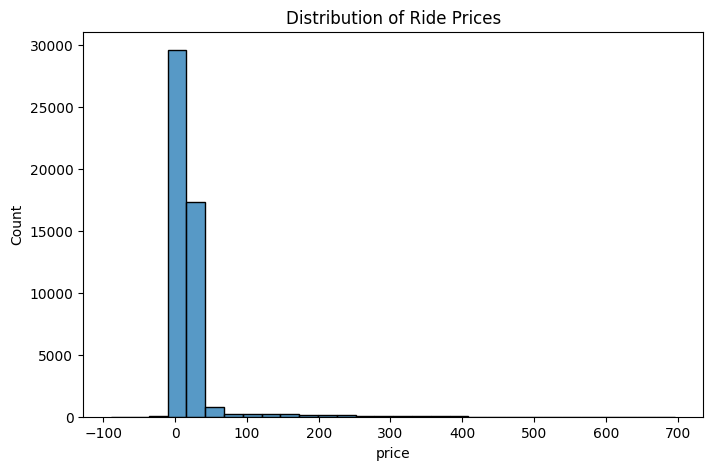

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30)
plt.title("Distribution of Ride Prices")
plt.show()

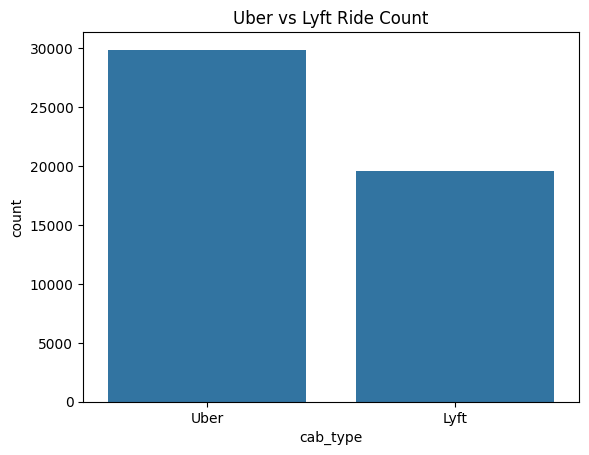

In [21]:
sns.countplot(x='cab_type', data=df)
plt.title("Uber vs Lyft Ride Count")
plt.show()

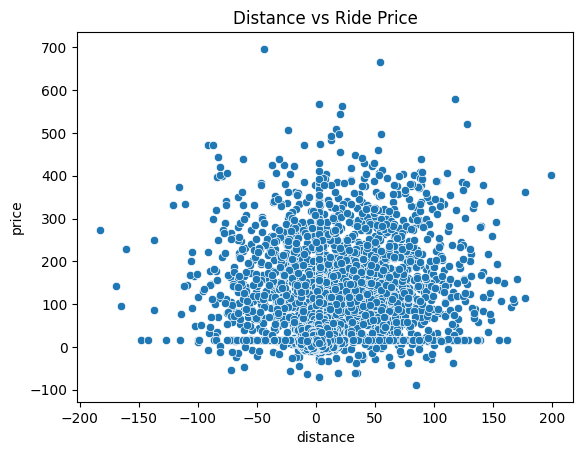

In [22]:
sns.scatterplot(x='distance', y='price', data=df)
plt.title("Distance vs Ride Price")
plt.show()

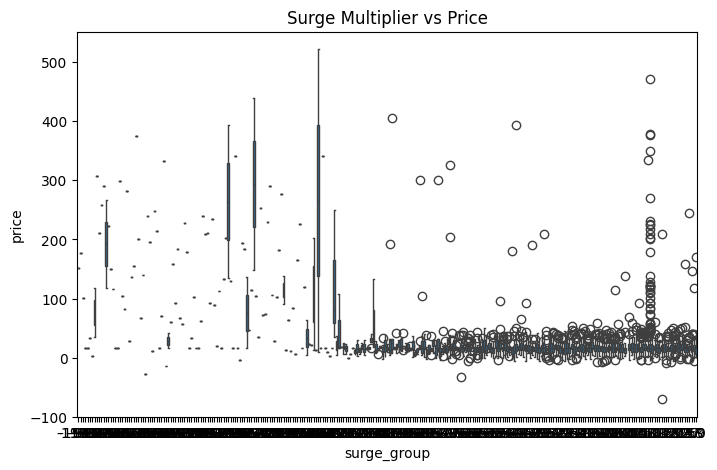

In [23]:
df_small = df[df['surge_multiplier'] <= 3].copy()

df_small = df_small.sample(5000)

df_small['surge_group'] = df_small['surge_multiplier'].round(1)

plt.figure(figsize=(8,5))
sns.boxplot(x='surge_group', y='price', data=df_small)

plt.title("Surge Multiplier vs Price")
plt.show()

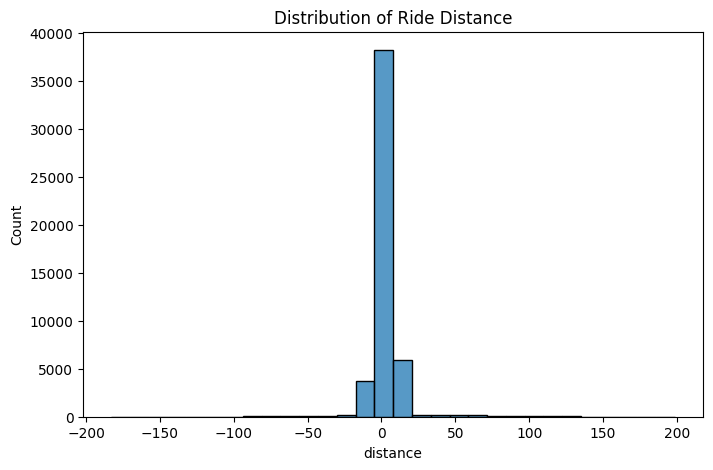

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['distance'], bins=30)
plt.title("Distribution of Ride Distance")
plt.show()

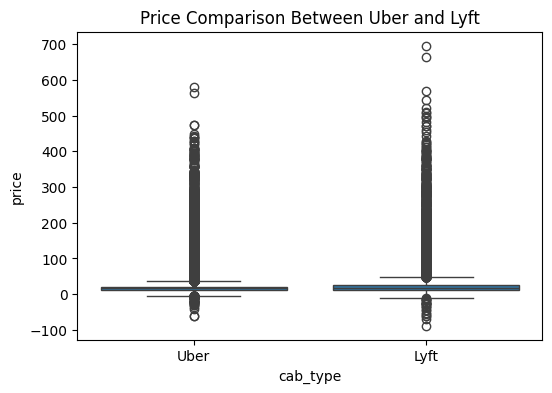

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='cab_type', y='price', data=df)
plt.title("Price Comparison Between Uber and Lyft")
plt.show()

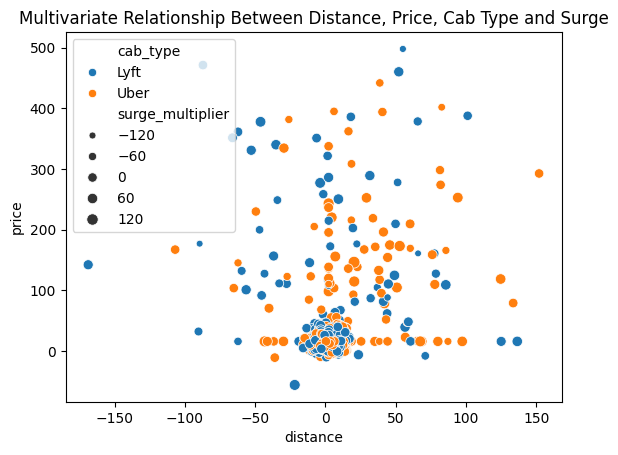

In [26]:
sns.scatterplot(
    x='distance',
    y='price',
    hue='cab_type',
    size='surge_multiplier',
    data=df.sample(3000)
)

plt.title("Multivariate Relationship Between Distance, Price, Cab Type and Surge")
plt.show()

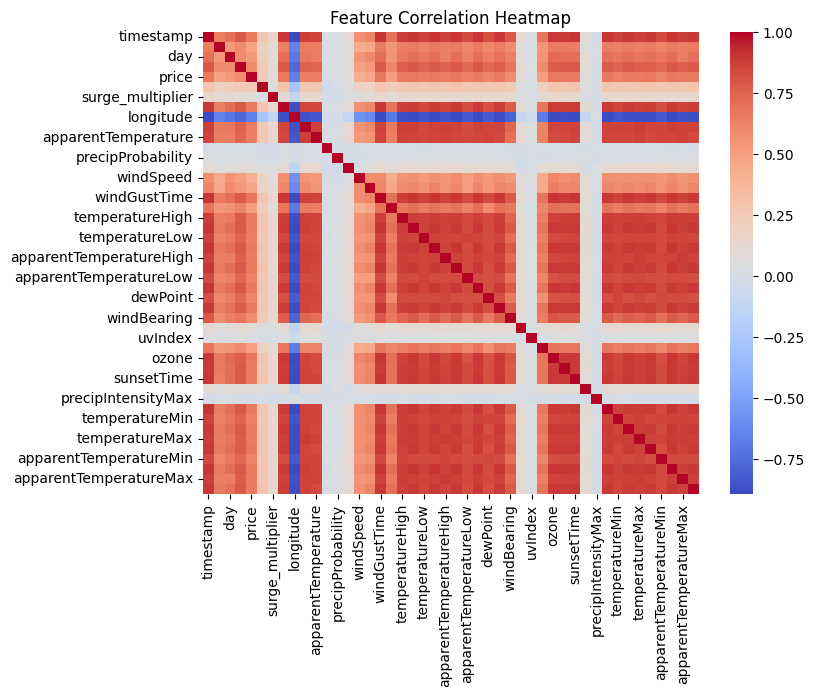

In [27]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

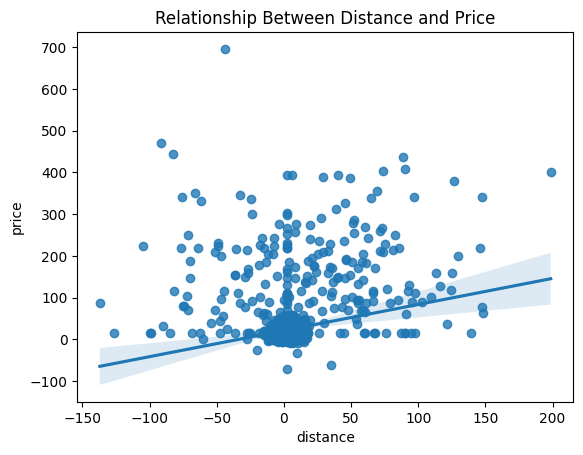

In [28]:
sns.regplot(x='distance', y='price', data=df.sample(5000))
plt.title("Relationship Between Distance and Price")
plt.show()

## Step 9: Feature Engineering
Feature engineering transforms raw variables into meaningful features that help the machine learning model better understand patterns in surge pricing.

In [29]:
# Fill missing numeric values
for col in ['distance', 'surge_multiplier']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [30]:
# Extract time features
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month

    df = df.drop('datetime', axis=1)

In [31]:
# Convert text columns into numeric features
if 'short_summary' in df.columns:
    df['short_summary_len'] = df['short_summary'].apply(lambda x: len(str(x)))
    df = df.drop('short_summary', axis=1)

if 'long_summary' in df.columns:
    df['long_summary_len'] = df['long_summary'].apply(lambda x: len(str(x)))
    df = df.drop('long_summary', axis=1)

## Step 10: Encoding Categorical Variables

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['cab_type'] = le.fit_transform(df['cab_type'])
df['name'] = le.fit_transform(df['name'])
df['source'] = le.fit_transform(df['source'])
df['destination'] = le.fit_transform(df['destination'])

df.head()

,timestamp,hour,day,month,timezone,source,destination,cab_type,name,price,...,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime,short_summary_len,long_summary_len
17863,1.543773e+09,8,3,12,America/New_York,7,9,1,8,15.533262,...,34.742255,1.543896e+09,67.402172,1.543788e+09,39.472905,1.543748e+09,62.556873,1.543853e+09,7,23
9549,1.543773e+09,14,29,11,America/New_York,9,1,0,4,34.490008,...,29.969116,1.543550e+09,40.718759,1.543788e+09,33.784997,1.543550e+09,33.583331,1.543511e+09,15,35
45510,1.543428e+09,17,28,11,America/New_York,1,6,1,11,15.687911,...,31.666452,1.543399e+09,44.626105,1.543439e+09,19.097819,1.543399e+09,37.529263,1.543439e+09,10,35
39180,1.543217e+09,7,26,11,America/New_York,6,0,1,1,23.393307,...,43.772520,1.543234e+09,46.348868,1.543255e+09,44.613082,1.543291e+09,44.326502,1.543788e+09,10,52
23366,1.543763e+09,14,2,12,America/New_York,4,8,1,1,15.533262,...,29.379571,1.543727e+09,51.151873,1.543788e+09,34.126067,1.543748e+09,45.609473,1.543788e+09,12,27


## Step 11: Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = df.select_dtypes(include=['float64','int64']).columns

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,timestamp,hour,day,month,timezone,source,destination,cab_type,name,price,...,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime,short_summary_len,long_summary_len
17863,-0.217785,8,3,12,America/New_York,7,9,1,8,-0.184432,...,-0.190623,-0.216107,0.044660,-0.215277,-0.039627,-0.217794,0.043494,-0.216382,-1.466360,-1.64598
9549,-0.217785,14,29,11,America/New_York,9,1,0,4,0.321380,...,-0.263776,-0.216227,-0.265740,-0.215277,-0.136301,-0.217862,-0.314565,-0.216501,1.089965,0.17154
45510,-0.217905,17,28,11,America/New_York,1,6,1,11,-0.180306,...,-0.237763,-0.216280,-0.220287,-0.215399,-0.385929,-0.217915,-0.265801,-0.216526,-0.507738,0.17154
39180,-0.217978,7,26,11,America/New_York,6,0,1,1,0.025293,...,-0.052225,-0.216337,-0.200247,-0.215463,0.047737,-0.217952,-0.181800,-0.216404,-0.507738,2.74636
23366,-0.217789,14,2,12,America/New_York,4,8,1,1,-0.184432,...,-0.272811,-0.216165,-0.144375,-0.215277,-0.130504,-0.217794,-0.165944,-0.216404,0.131343,-1.04014


## Step 12: Correlation Analysis

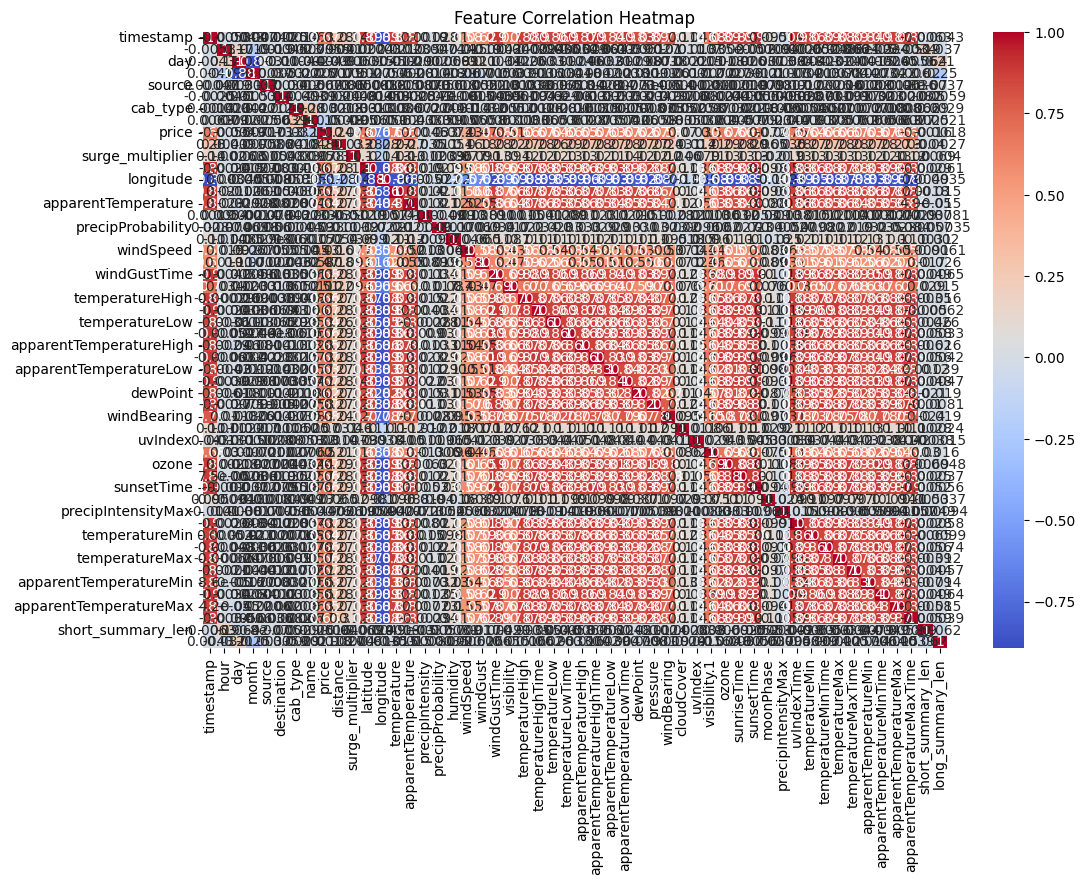

In [34]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Step 13: Feature Encoding

In [35]:
cols_to_encode = ['cab_type', 'source', 'destination', 'name', 'timezone', 'icon']

cols_to_encode = [col for col in cols_to_encode if col in df.columns]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

df = df.select_dtypes(exclude=['object'])

print("Encoding done. Shape:", df.shape)

Encoding done. Shape: (49504, 89)


Feature selection is performed to retain only the most relevant variables that influence ride pricing and surge behavior while removing unnecessary columns.

## Step 14: Preparing Data for Machine Learning

In [36]:
X = df.drop(columns=['price'])
y = df['price']



In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 15: Model Training (Gradient Boosting Regressor)
Gradient Boosting Regressor is used to predict ride price based on
features like distance, location, and ride type.

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42)

model.fit(X_train, y_train)
print("Training done successfully")

Training done successfully


In [39]:
predictions = model.predict(X_test)

predictions[:10]

array([ 0.10521294, -0.28982584, -0.26764892, -0.16495556, -0.16495556,
       -0.16495556, -0.1870099 , -0.26764892, -0.1870099 , -0.26420251])

## Step 16: Model Evaluation

In [40]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.32052818729203664
RMSE: 0.566152088481564
R2 Score: 0.6916312285485609


## Step 17: Residual Analysis

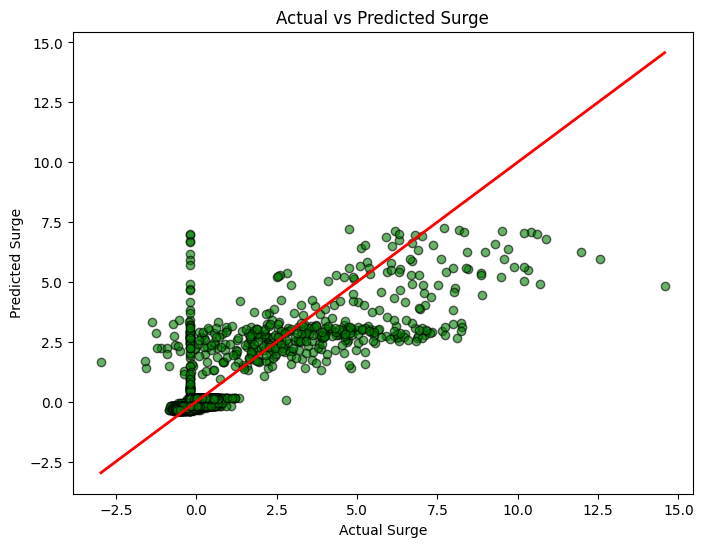

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions,
            color='green',
            alpha=0.6,
            edgecolors='black')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Surge")
plt.ylabel("Predicted Surge")
plt.title("Actual vs Predicted Surge")
plt.show()

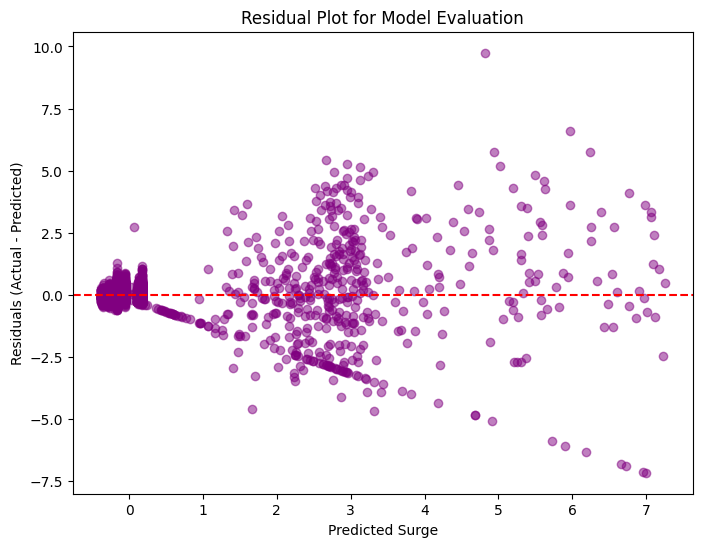

In [42]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))
plt.scatter(predictions, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Surge")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Model Evaluation")

plt.show()

## Key Insights

• Ride prices increase with ride distance.

• Surge multiplier significantly affects ride prices.

• Uber and Lyft show similar ride demand patterns.

• Data cleaning improved dataset quality by removing duplicates and handling missing values.

## Conclusion

This project analyzed ride-hailing data to identify factors influencing surge pricing. Data cleaning and exploratory analysis helped uncover patterns between ride distance, surge multiplier, and ride price.

The dataset was successfully prepared for machine learning, and a Gradient Boosting Regressor model was used to predict surge multipliers. The analysis demonstrates how data preprocessing and feature engineering improve predictive modeling performance.